
Scholarship descriptions kept:
descr
LGS SCHOLARSHIP-TUITION           601
Sum LGS SCHOLARSHIP-TUITION       246
LGS-MDP-COVERDELL-FELLOWSH         38
LGS-BIOETH-Shields-SCHOLARSHIP      6
LGS-MDP-Sheth-SCHOLARSHIP           5
LGS-MDP-Whatcom-Scholarship         4
SumLGS-BIOETH-Shields-SCHOLAR       1
LGS Scholarship-TU-HHS              1
LGS-CSMS-NEMATI-SUPPORT             1
LGS-MDP-IDN-SCHOLARSHIP             1
SumLGS-CSMS-NEMATI-SUPPORT          1
Name: count, dtype: int64

Program summary:
                 program  students  avg_tuition  avg_scholarship  \
0                    MDP       135   108,230.99        59,519.39   
1       Computer Science       154    65,700.89        32,250.42   
2              Bioethics        68    53,545.27         5,124.66   
3     Cancer Biology 4+1        28    61,501.07        15,930.86   
4          Bioethics 4+1        27    45,221.70         7,199.00   
5                   Math        19    57,857.68        23,709.58   
6           Data Science

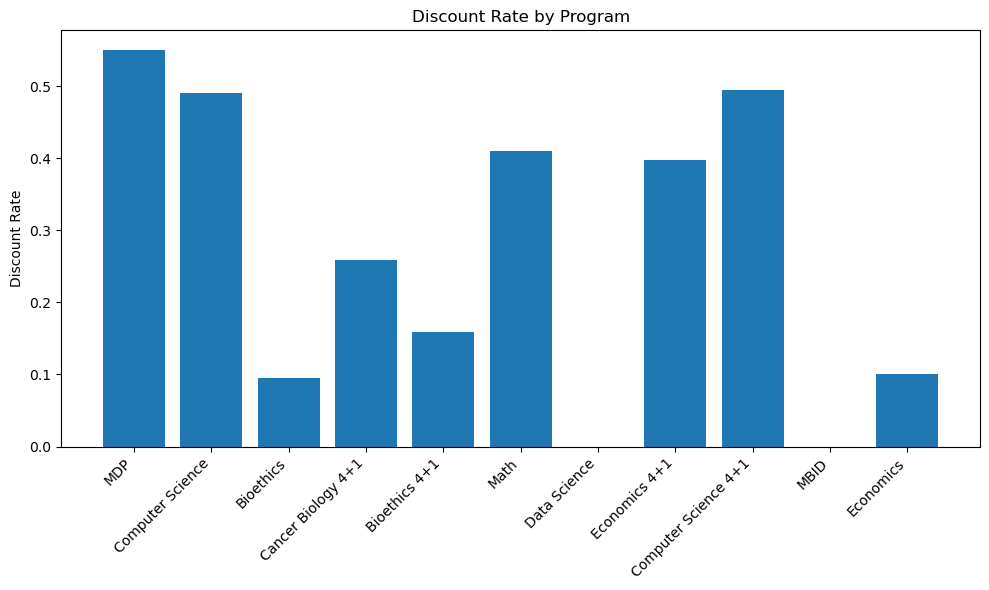

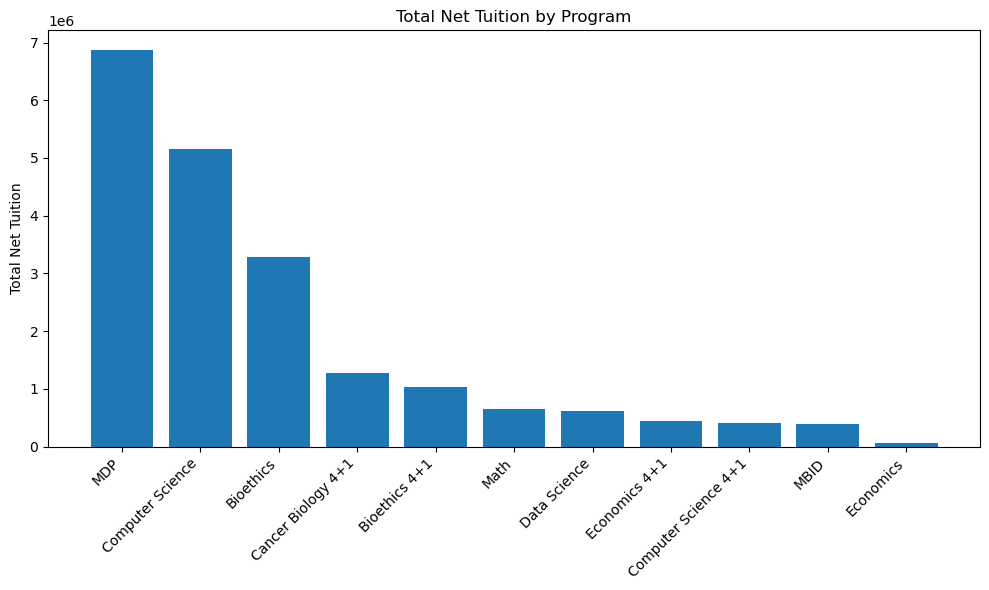

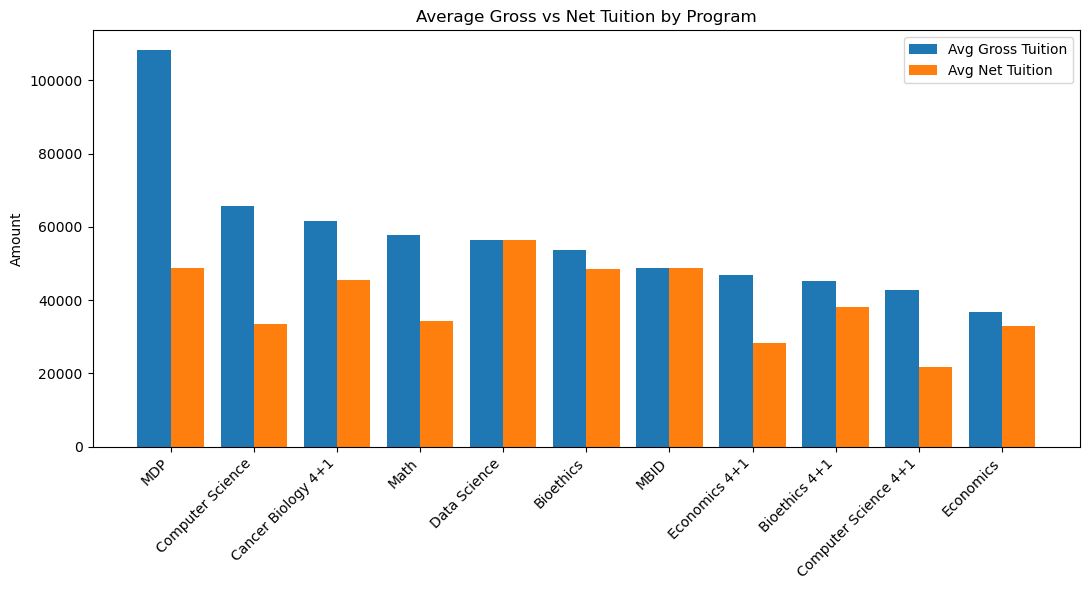


Saved:
- program_summary_output.xlsx
- student_program_level_output.xlsx


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# LOAD DATA
# ----------------------------
file_path = "Tuition Data.xlsx"

tuition = pd.read_excel(file_path, sheet_name="Gross Tuition Billed to Student")
scholarship = pd.read_excel(file_path, sheet_name="Tuition Scholarship given to st")

# strip hidden spaces just in case
tuition.columns = tuition.columns.str.strip()
scholarship.columns = scholarship.columns.str.strip()

# ----------------------------
# CLEAN TUITION DATA
# ----------------------------
tuition = tuition.rename(columns={
    "Gross Tuition": "tuition",
    "Acad Plan": "acad_plan"
})

tuition = tuition[["ID", "acad_plan", "tuition"]].copy()
tuition["tuition"] = pd.to_numeric(tuition["tuition"], errors="coerce")
tuition = tuition.dropna(subset=["acad_plan", "tuition"])

# ----------------------------
# CLEAN SCHOLARSHIP DATA
# ----------------------------
scholarship = scholarship.rename(columns={
    "Academic Plan": "acad_plan",
    "Descr": "descr",
    "Fall Tuition Scholarship": "fall_sch",
    "Spring Tuiiton Scholarship": "spring_sch",
    "Summer Tuition Scholarship": "summer_sch"
})

for col in ["fall_sch", "spring_sch", "summer_sch"]:
    scholarship[col] = pd.to_numeric(scholarship[col], errors="coerce").fillna(0)

scholarship["scholarship"] = (
    scholarship["fall_sch"] +
    scholarship["spring_sch"] +
    scholarship["summer_sch"]
)

scholarship = scholarship[["ID", "acad_plan", "descr", "scholarship"]].copy()

# ----------------------------
# PROGRAM MAP
# ----------------------------
program_map = {
    "COMPSCIMS": "Computer Science",
    "CS4P1MS": "Computer Science 4+1",
    "DATASCIMS": "Data Science",
    "QTMMS": "Data Science",
    "ECONMS": "Economics",
    "ECON4P1MS": "Economics 4+1",
    "MATHMS": "Math",
    "BIOETHMA": "Bioethics",
    "BIOETH4P1": "Bioethics 4+1",
    "DEVPRACMDP": "MDP",
    "HUMANRTCRT": "MDP",
    "BMIDMS": "MBID",
    "BBS4P1MS": "Cancer Biology 4+1"
}

tuition = tuition[tuition["acad_plan"].isin(program_map.keys())].copy()
scholarship = scholarship[scholarship["acad_plan"].isin(program_map.keys())].copy()

# ----------------------------
# FILTER SCHOLARSHIPS
# ----------------------------
# Based on your cheat sheet:
# keep LGS/program tuition scholarships
# exclude training grants, GRFP, and clearly external/general scholarships

exclude_terms = [
    "nih", "nsf", "grfp", "training grant", "special-scholarship",
    "yellow ribbon", "vet", "americorps", "pell", "hope", "zell",
    "woodruff scholar-grad tuition"
]

def keep_scholarship(descr):
    if pd.isna(descr):
        return False

    d = str(descr).lower().strip()

    # exclude obvious non-target awards
    if any(term in d for term in exclude_terms):
        return False

    # keep LGS tuition scholarships and program-specific LGS awards
    if "lgs" in d:
        return True

    return False

scholarship = scholarship[scholarship["descr"].apply(keep_scholarship)].copy()

# ----------------------------
# OPTIONAL CHECK: WHICH SCHOLARSHIPS WERE KEPT
# ----------------------------
print("\nScholarship descriptions kept:")
print(scholarship["descr"].value_counts().head(30))

# ----------------------------
# AGGREGATE TO STUDENT-PROGRAM LEVEL
# ----------------------------
tuition_grouped = (
    tuition.groupby(["ID", "acad_plan"], as_index=False)["tuition"]
    .sum()
)

scholarship_grouped = (
    scholarship.groupby(["ID", "acad_plan"], as_index=False)["scholarship"]
    .sum()
)

# merge
df = pd.merge(
    tuition_grouped,
    scholarship_grouped,
    on=["ID", "acad_plan"],
    how="left"
)

df["scholarship"] = df["scholarship"].fillna(0)
df["program"] = df["acad_plan"].map(program_map)
df["net_tuition"] = df["tuition"] - df["scholarship"]

# ----------------------------
# PROGRAM-LEVEL SUMMARY
# ----------------------------
program_summary = (
    df.groupby("program", as_index=False)
    .agg(
        students=("ID", "nunique"),
        avg_tuition=("tuition", "mean"),
        avg_scholarship=("scholarship", "mean"),
        avg_net_tuition=("net_tuition", "mean"),
        total_gross_tuition=("tuition", "sum"),
        total_scholarship=("scholarship", "sum"),
        total_net_tuition=("net_tuition", "sum")
    )
)

program_summary["discount_rate"] = (
    program_summary["total_scholarship"] / program_summary["total_gross_tuition"]
)

program_summary = program_summary.sort_values(
    by="total_net_tuition",
    ascending=False
).reset_index(drop=True)

# format for readability
pd.options.display.float_format = "{:,.2f}".format

print("\nProgram summary:")
print(program_summary)

# ----------------------------
# CHART 1: DISCOUNT RATE BY PROGRAM
# ----------------------------
plt.figure(figsize=(10, 6))
plt.bar(program_summary["program"], program_summary["discount_rate"])
plt.xticks(rotation=45, ha="right")
plt.title("Discount Rate by Program")
plt.ylabel("Discount Rate")
plt.tight_layout()
plt.show()

# ----------------------------
# CHART 2: TOTAL NET TUITION BY PROGRAM
# ----------------------------
plt.figure(figsize=(10, 6))
plt.bar(program_summary["program"], program_summary["total_net_tuition"])
plt.xticks(rotation=45, ha="right")
plt.title("Total Net Tuition by Program")
plt.ylabel("Total Net Tuition")
plt.tight_layout()
plt.show()

# ----------------------------
# CHART 3: AVG GROSS VS AVG NET TUITION
# ----------------------------
plot_df = program_summary.sort_values("avg_tuition", ascending=False)

x = range(len(plot_df))
width = 0.4

plt.figure(figsize=(11, 6))
plt.bar([i - width/2 for i in x], plot_df["avg_tuition"], width=width, label="Avg Gross Tuition")
plt.bar([i + width/2 for i in x], plot_df["avg_net_tuition"], width=width, label="Avg Net Tuition")
plt.xticks(list(x), plot_df["program"], rotation=45, ha="right")
plt.title("Average Gross vs Net Tuition by Program")
plt.ylabel("Amount")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# SAVE OUTPUT
# ----------------------------
program_summary.to_excel("program_summary_output.xlsx", index=False)
df.to_excel("student_program_level_output.xlsx", index=False)

print("\nSaved:")
print("- program_summary_output.xlsx")
print("- student_program_level_output.xlsx")

In [21]:
print(tuition.columns)
print(scholarship.columns)

Index(['ID', 'acad_plan', 'tuition'], dtype='object')
Index(['ID', 'acad_plan', 'descr', 'scholarship'], dtype='object')


In [7]:
# ----------------------------
# ADD INTERNATIONAL STUDENT %
# ----------------------------

# reload scholarship sheet so we can use the demographic column cleanly
scholarship_full = pd.read_excel(file_path, sheet_name="Tuition Scholarship given to st")
scholarship_full.columns = scholarship_full.columns.str.strip()

scholarship_full = scholarship_full.rename(columns={
    "Academic Plan": "acad_plan"
})

# keep only programs in your analysis
scholarship_full = scholarship_full[scholarship_full["acad_plan"].isin(program_map.keys())].copy()

# create international flag
scholarship_full["intl"] = scholarship_full["EU CC IPEDS"].apply(
    lambda x: 1 if str(x).strip() == "Non US Citizen" else 0
)

# one row per student-program
intl_df = scholarship_full.groupby(["ID", "acad_plan"], as_index=False)["intl"].max()

# merge into your existing df
df = pd.merge(df, intl_df, on=["ID", "acad_plan"], how="left")
df["intl"] = df["intl"].fillna(0)

# rebuild program summary with intl counts
program_summary = (
    df.groupby("program", as_index=False)
    .agg(
        students=("ID", "nunique"),
        intl_students=("intl", "sum"),
        avg_tuition=("tuition", "mean"),
        avg_scholarship=("scholarship", "mean"),
        avg_net_tuition=("net_tuition", "mean"),
        total_gross_tuition=("tuition", "sum"),
        total_scholarship=("scholarship", "sum"),
        total_net_tuition=("net_tuition", "sum")
    )
)

program_summary["discount_rate"] = (
    program_summary["total_scholarship"] / program_summary["total_gross_tuition"]
)

program_summary["intl_pct"] = (
    program_summary["intl_students"] / program_summary["students"]
)

program_summary = program_summary.sort_values(
    by="total_net_tuition",
    ascending=False
).reset_index(drop=True)

print(program_summary[[
    "program", "students", "intl_students", "intl_pct",
    "avg_tuition", "avg_scholarship", "avg_net_tuition", "discount_rate"
]])

program_summary["intl_pct"] = program_summary["intl_pct"] * 100
program_summary["discount_rate"] = program_summary["discount_rate"] * 100

print(program_summary[[
    "program", "students", "intl_students", "intl_pct", "discount_rate"
]])

                 program  students  intl_students  intl_pct  avg_tuition  \
0                    MDP       135          39.00      0.29   108,230.99   
1       Computer Science       154         133.00      0.86    65,700.89   
2              Bioethics        68           0.00      0.00    53,545.27   
3     Cancer Biology 4+1        28           4.00      0.14    61,501.07   
4          Bioethics 4+1        27           2.00      0.07    45,221.70   
5                   Math        19           8.00      0.42    57,857.68   
6           Data Science        11           0.00      0.00    56,451.64   
7          Economics 4+1        16           4.00      0.25    46,712.50   
8   Computer Science 4+1        19           5.00      0.26    42,788.63   
9                   MBID         8           0.00      0.00    48,800.00   
10             Economics         2           1.00      0.50    36,600.00   

    avg_scholarship  avg_net_tuition  discount_rate  
0         59,519.39        48,711

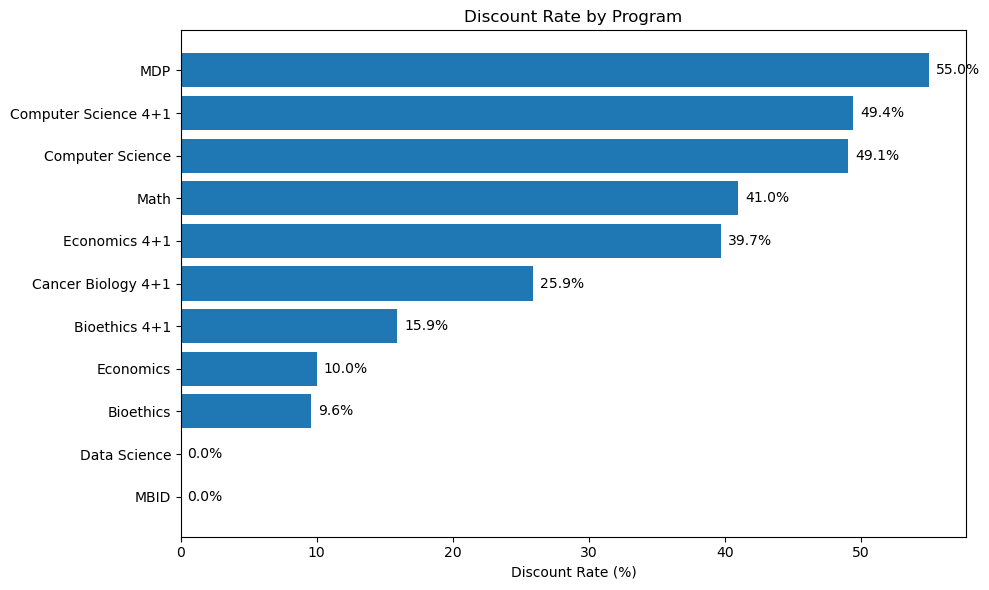

In [12]:
import matplotlib.pyplot as plt

plot_df = program_summary.sort_values("discount_rate", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(plot_df["program"], plot_df["discount_rate"])
plt.xlabel("Discount Rate (%)")
plt.title("Discount Rate by Program")
plt.gca().invert_yaxis()

for i, v in enumerate(plot_df["discount_rate"]):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.show()

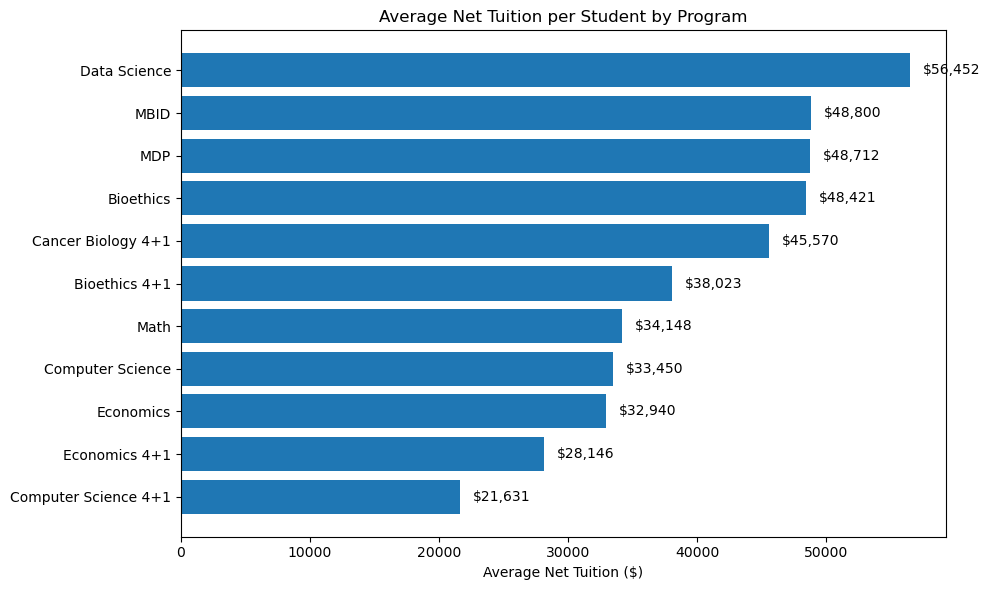

In [9]:
plot_df = program_summary.sort_values("avg_net_tuition", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(plot_df["program"], plot_df["avg_net_tuition"])
plt.xlabel("Average Net Tuition ($)")
plt.title("Average Net Tuition per Student by Program")
plt.gca().invert_yaxis()

for i, v in enumerate(plot_df["avg_net_tuition"]):
    plt.text(v + 1000, i, f"${v:,.0f}", va='center')

plt.tight_layout()
plt.show()

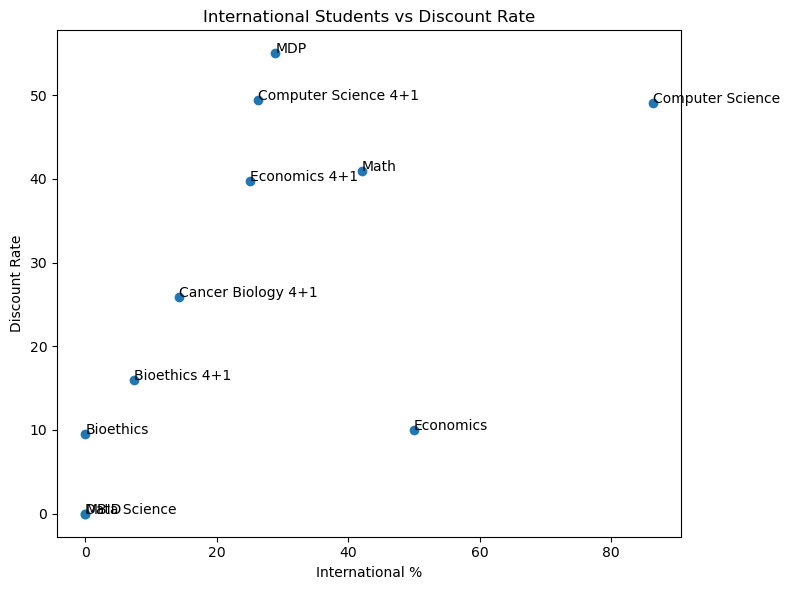

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(program_summary["intl_pct"], program_summary["discount_rate"])

for i, row in program_summary.iterrows():
    plt.text(row["intl_pct"], row["discount_rate"], row["program"])

plt.xlabel("International %")
plt.ylabel("Discount Rate")
plt.title("International Students vs Discount Rate")

plt.tight_layout()
plt.show()

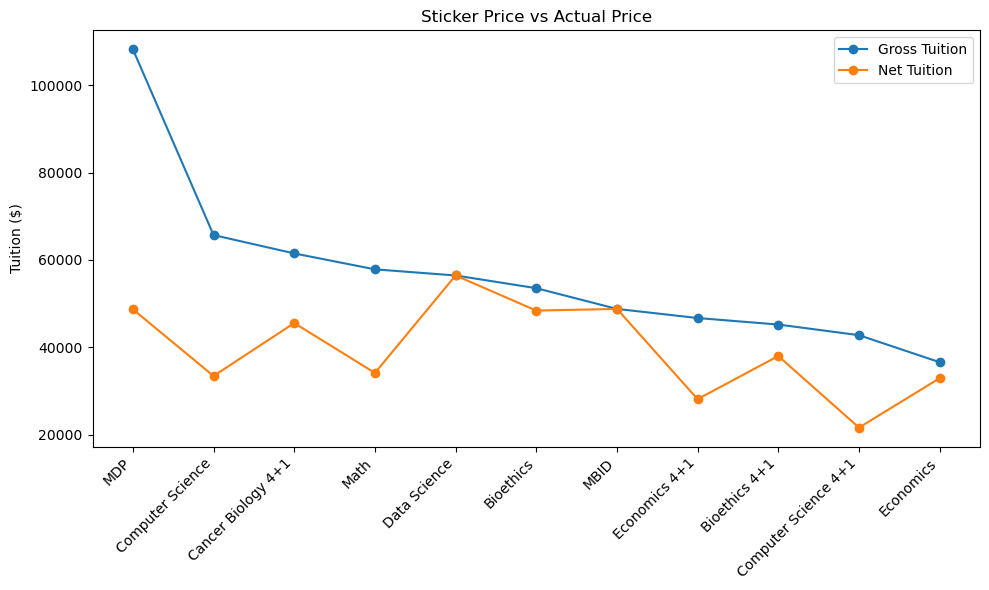

In [11]:
plot_df = program_summary.sort_values("avg_tuition", ascending=False)

plt.figure(figsize=(10,6))

plt.plot(plot_df["program"], plot_df["avg_tuition"], marker='o', label="Gross Tuition")
plt.plot(plot_df["program"], plot_df["avg_net_tuition"], marker='o', label="Net Tuition")

plt.xticks(rotation=45, ha='right')
plt.ylabel("Tuition ($)")
plt.title("Sticker Price vs Actual Price")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
peer_data = pd.DataFrame([
    # DATA / CS
    {"school": "Columbia", "program_group": "Data/CS", "tuition": 64800},
    {"school": "NYU", "program_group": "Data/CS", "tuition": 75750},
    {"school": "Georgia Tech", "program_group": "Data/CS", "tuition": 39500},

    # ECON
    {"school": "Columbia", "program_group": "Economics", "tuition": 90732},
    {"school": "NYU", "program_group": "Economics", "tuition": 70000},
    {"school": "Georgia Tech", "program_group": "Economics", "tuition": 41390},

    # GENERAL
    {"school": "Columbia", "program_group": "General", "tuition": 73456},
    {"school": "NYU", "program_group": "General", "tuition": 70000},
    {"school": "Georgia Tech", "program_group": "General", "tuition": 31210},
])

In [27]:
# ----------------------------
# GROSS TUITION (ANNUALIZED CORRECTLY)
# ----------------------------
tuition_gross = pd.read_excel(file_path, sheet_name="Gross Tuition Billed to Student")
tuition_gross.columns = tuition_gross.columns.str.strip()

tuition_gross = tuition_gross.rename(columns={
    "Gross Tuition": "tuition",
    "Acad Plan": "acad_plan"
})

tuition_gross = tuition_gross[["ID", "acad_plan", "tuition"]].copy()
tuition_gross["tuition"] = pd.to_numeric(tuition_gross["tuition"], errors="coerce")
tuition_gross = tuition_gross.dropna(subset=["acad_plan", "tuition"])

# keep only mapped programs
tuition_gross = tuition_gross[tuition_gross["acad_plan"].isin(program_map.keys())].copy()
tuition_gross["program"] = tuition_gross["acad_plan"].map(program_map)

# ----------------------------
# STEP 1: STUDENT-LEVEL ANNUAL TUITION
# ----------------------------
student_program = (
    tuition_gross.groupby(["ID", "program"], as_index=False)
    .agg(total_tuition=("tuition", "sum"),
         term_count=("tuition", "count"))
)

# annualize (handles 1-term vs 2-term students)
student_program["annual_tuition"] = (
    student_program["total_tuition"] * (2 / student_program["term_count"])
)

# ----------------------------
# STEP 2: PROGRAM-LEVEL AVERAGE
# ----------------------------
program_summary_gross = (
    student_program.groupby("program", as_index=False)
    .agg(
        students=("ID", "nunique"),
        avg_tuition=("annual_tuition", "mean")
    )
)

# ----------------------------
# PROGRAM GROUPING
# ----------------------------
def map_group(program):
    program = program.lower()

    if any(x in program for x in ["computer", "data", "analytics"]):
        return "Data/CS"
    elif any(x in program for x in ["econ", "quant", "math"]):
        return "Economics"
    else:
        return "General"

emory_grouped_gross = program_summary_gross.copy()
emory_grouped_gross["program_group"] = emory_grouped_gross["program"].apply(map_group)

# ----------------------------
# GROUP LEVEL (FINAL EMORY NUMBERS)
# ----------------------------
emory_group_summary = (
    emory_grouped_gross.groupby("program_group", as_index=False)
    .agg(tuition=("avg_tuition", "mean"))
)

emory_group_summary["school"] = "Emory"

# ----------------------------
# COMBINE WITH PEERS
# ----------------------------
combined = pd.concat([
    peer_data,
    emory_group_summary[["school", "program_group", "tuition"]]
], ignore_index=True)

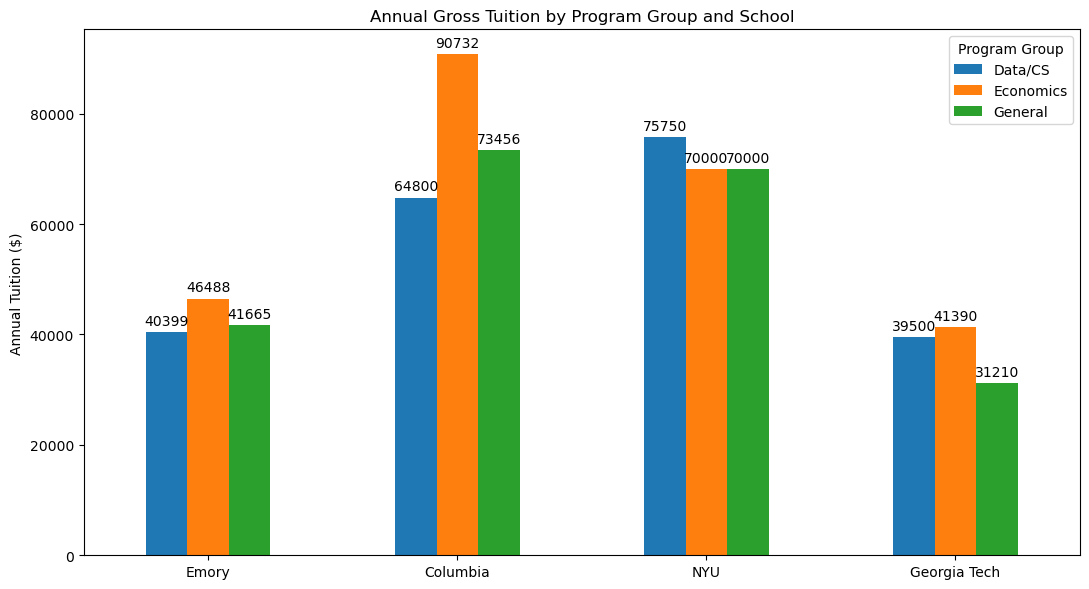

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# COMBINE EMORY + PEERS
# ----------------------------
combined = pd.concat([
    peer_data,
    emory_group_summary[["school", "program_group", "tuition"]]
], ignore_index=True)

# make sure order is consistent
school_order = ["Emory", "Columbia", "NYU", "Georgia Tech"]
group_order = ["Data/CS", "Economics", "General"]

combined["school"] = pd.Categorical(combined["school"], categories=school_order, ordered=True)
combined["program_group"] = pd.Categorical(combined["program_group"], categories=group_order, ordered=True)

# pivot for grouped bar chart
pivot = combined.pivot(index="school", columns="program_group", values="tuition")
pivot = pivot.loc[school_order, group_order]

# ----------------------------
# PLOT
# ----------------------------
ax = pivot.plot(kind="bar", figsize=(11, 6))

plt.title("Annual Gross Tuition by Program Group and School")
plt.ylabel("Annual Tuition ($)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Program Group")
plt.tight_layout()

# add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.show()

In [30]:
print(tuition_gross.head(20))

         ID acad_plan   tuition    program
0     39261  BIOETHMA    464.40  Bioethics
1    391080  BIOETHMA  9,288.00  Bioethics
2    398337  BIOETHMA  4,644.00  Bioethics
3   1605332  BIOETHMA 25,000.00  Bioethics
4   1823126  BIOETHMA 20,900.00  Bioethics
5   1849711  BIOETHMA 20,900.00  Bioethics
6   1911122  BIOETHMA  9,288.00  Bioethics
7   1949008  BIOETHMA  6,966.00  Bioethics
8   2150241  BIOETHMA 20,900.00  Bioethics
10  2152681  BIOETHMA 11,610.00  Bioethics
11  2222027  BIOETHMA 20,900.00  Bioethics
13  2298904  BIOETHMA 20,900.00  Bioethics
14  2326431  BIOETHMA 20,900.00  Bioethics
15  2335810  BIOETHMA 20,900.00  Bioethics
16    39261  BIOETHMA  2,322.00  Bioethics
17   358409  BIOETHMA  2,322.00  Bioethics
18   391080  BIOETHMA  6,966.00  Bioethics
19   398337  BIOETHMA  4,644.00  Bioethics
20  1823126  BIOETHMA 20,900.00  Bioethics
22  1849711  BIOETHMA 20,900.00  Bioethics
